In [17]:
# BƯỚC 1 — Import
import pandas as pd
import numpy as np
import seaborn as sns
import sqlite3
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score as roc
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample  # thêm

In [18]:
# BƯỚC 2 — Load data qua SQLite (giữ nguyên)
df_raw = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')
conn = sqlite3.connect('credit_card.db')
df_raw.to_sql('transactions', conn, if_exists='replace', index=False)
dataset = pd.read_sql_query("SELECT * FROM transactions LIMIT 5", conn)
dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<Axes: xlabel='Class', ylabel='count'>

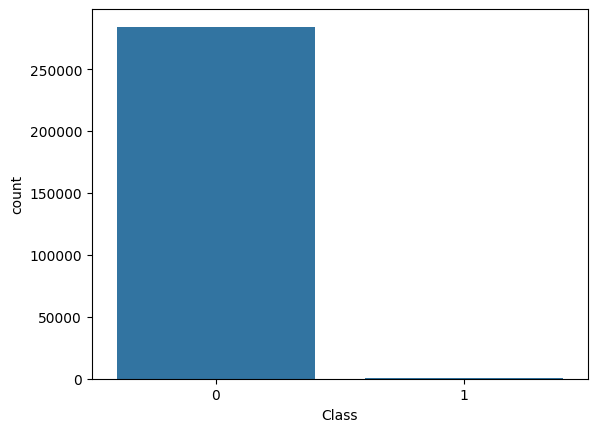

In [19]:
# BƯỚC 3 — Visualize imbalance (giữ nguyên)
all_data = pd.read_sql_query("SELECT Class FROM transactions", conn)
sns.countplot(x='Class', data=all_data)

In [20]:
# BƯỚC 4 — Tách fraud/normal qua SQL (giữ nguyên)
positiveDataset = pd.read_sql_query("SELECT * FROM transactions WHERE Class = 1", conn)
negativeDataset = pd.read_sql_query("SELECT * FROM transactions WHERE Class = 0", conn)
conn.close()

<Axes: xlabel='Class', ylabel='count'>

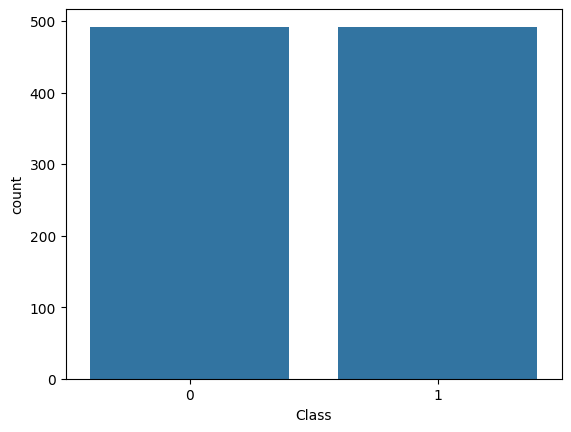

In [21]:
# BƯỚC 5 — Xử lý imbalance bằng undersampling (thêm mới)
negativeDataset_down = resample(
    negativeDataset,
    n_samples=len(positiveDataset),  # 492 rows
    random_state=21
)
balancedDataset = pd.concat([positiveDataset, negativeDataset_down])

# Visualize lại sau khi undersample
sns.countplot(x='Class', data=balancedDataset)

In [22]:
# BƯỚC 6 — Split train/test (sửa lại)
X = balancedDataset.drop(columns=['Class'])
y = balancedDataset['Class']

xTrain, xTest, yTrain, yTest = tts(
    X, y,
    test_size=0.2,
    random_state=21,
    stratify=y
)

In [23]:
# BƯỚC 7 — Khởi tạo model (giữ nguyên, chỉ bỏ max_depth=3)
classifier = RandomForestClassifier(n_estimators=500, random_state=21)


In [24]:
# BƯỚC 8 — Scale (sửa data leakage)
scaler = StandardScaler()
xTrain = scaler.fit_transform(xTrain)
xTest = scaler.transform(xTest)  # đổi từ fit_transform → transform

In [25]:
# BƯỚC 9 — Train (giữ nguyên)
classifier.fit(xTrain, yTrain)

RandomForestClassifier(n_estimators=500, random_state=21)

In [26]:
# BƯỚC 10 — Evaluate train (giữ nguyên)
predTrain = classifier.predict(xTrain)
print(classification_report(yTrain, predTrain))
print('ROC AUC Score: ', roc(yTrain, predTrain))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       394
           1       1.00      1.00      1.00       393

    accuracy                           1.00       787
   macro avg       1.00      1.00      1.00       787
weighted avg       1.00      1.00      1.00       787

ROC AUC Score:  1.0


In [27]:
# BƯỚC 11 — Evaluate test (giữ nguyên)
predTest = classifier.predict(xTest)
print(classification_report(yTest, predTest))
print('ROC AUC Score: ', roc(yTest, predTest))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94        98
           1       0.97      0.91      0.94        99

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197

ROC AUC Score:  0.9392393320964749
